# Module 3 — Habitable Zone Classification
### NASA PSCompPars Exoplanet Dataset
Classifying planets using Kopparapu et al. (2013) insolation flux thresholds:
- **Too Hot:** pl_insol > 1.1 S⊕
- **Habitable Zone:** 0.36 ≤ pl_insol ≤ 1.1 S⊕
- **Too Cold:** pl_insol < 0.36 S⊕
- **Unknown:** pl_insol missing

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

df = pd.read_csv(
    Path.home() / 'Downloads' / 'PSCompPars_2026.06.30_11.22.37.csv',
    comment='#', low_memory=False
)
print(f'Loaded {len(df):,} planets')

Loaded 6,298 planets


In [2]:
# Step 1 — classify every planet
conditions = [
    df['pl_insol'] > 1.1,
    (df['pl_insol'] >= 0.36) & (df['pl_insol'] <= 1.1),
    df['pl_insol'] < 0.36,
    df['pl_insol'].isna()
]
labels = ['Too Hot', 'Habitable Zone', 'Too Cold', 'Unknown']

df['hz_class'] = np.select(conditions, labels, default='Unknown')

print('Classification counts:')
print(df['hz_class'].value_counts())

Classification counts:
hz_class
Too Hot           5124
Unknown            576
Too Cold           412
Habitable Zone     186
Name: count, dtype: int64


In [3]:
# Step 2 — filter to Transit and Radial Velocity only
two_methods = ['Transit', 'Radial Velocity']
df_filtered = df[df['discoverymethod'].isin(two_methods)]

# Step 3 — count and calculate percentages
counts = df_filtered.groupby(['discoverymethod', 'hz_class']).size().reset_index(name='count')
counts['percentage'] = counts.groupby('discoverymethod')['count'].transform(
    lambda x: x / x.sum() * 100
)

print(counts.to_string(index=False))

discoverymethod       hz_class  count  percentage
Radial Velocity Habitable Zone    134   11.298482
Radial Velocity       Too Cold    306   25.801012
Radial Velocity        Too Hot    710   59.865093
Radial Velocity        Unknown     36    3.035413
        Transit Habitable Zone     51    1.096067
        Transit       Too Cold     15    0.322373
        Transit        Too Hot   4374   94.003868
        Transit        Unknown    213    4.577692


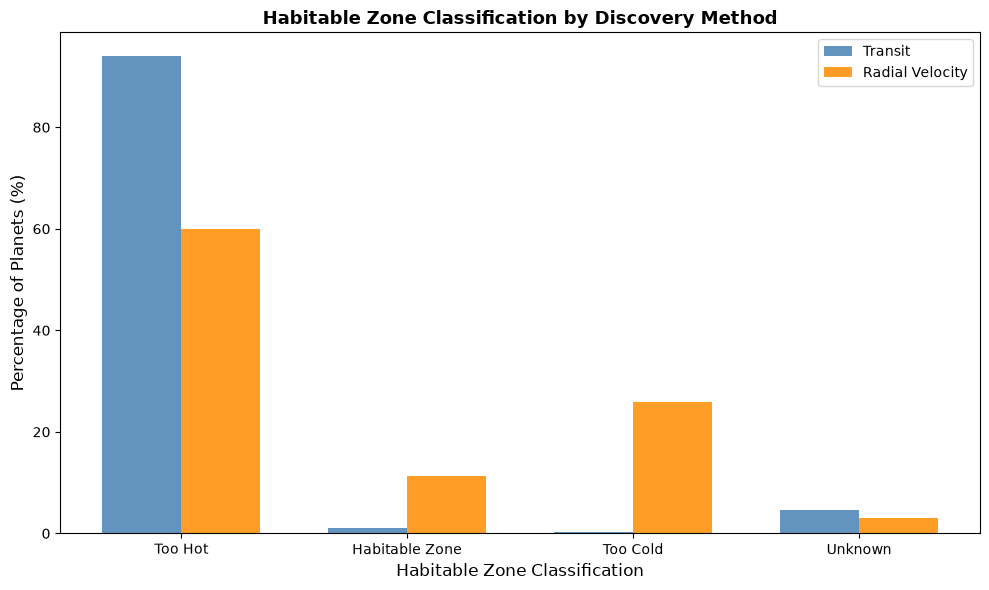

Saved hz_classification.png


In [4]:
# Step 4 — grouped bar chart
fig, ax = plt.subplots(figsize=(10, 6))

categories = ['Too Hot', 'Habitable Zone', 'Too Cold', 'Unknown']
methods = ['Transit', 'Radial Velocity']
colors = {'Transit': 'steelblue', 'Radial Velocity': 'darkorange'}

x = np.arange(len(categories))
width = 0.35

for i, method in enumerate(methods):
    method_data = counts[counts['discoverymethod'] == method]
    percentages = [
        method_data[method_data['hz_class'] == cat]['percentage'].values[0]
        if cat in method_data['hz_class'].values else 0
        for cat in categories
    ]
    ax.bar(x + i * width, percentages, width, label=method, color=colors[method], alpha=0.85)

ax.set_xlabel('Habitable Zone Classification', fontsize=12)
ax.set_ylabel('Percentage of Planets (%)', fontsize=12)
ax.set_title('Habitable Zone Classification by Discovery Method', fontsize=13, fontweight='bold')
ax.set_xticks(x + width / 2)
ax.set_xticklabels(categories)
ax.legend()

plt.tight_layout()
plt.savefig('hz_classification.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved hz_classification.png')